mediapipe : 0.10.13
opencv    : 4.13.0
pandas    : 2.3.3
numpy     : 2.2.6

All imports OK
✅ Config OK — 32 classes
   Classes    : ['ain', 'al', 'aleff', 'bb', 'dal', 'dha', 'dhad', 'fa', 'gaaf', 'ghain', 'ha', 'haa', 'jeem', 'kaaf', 'khaa', 'la', 'laam', 'meem', 'nun', 'ra', 'saad', 'seen', 'sheen', 'ta', 'taa', 'thaa', 'thal', 'toot', 'waw', 'ya', 'yaa', 'zay']
   Output CSV : /Users/nadinehassan/Desktop/sign_language_translator_2/sign_language_translator/datasets 2/landmarks.csv
✅ Functions defined
   - yolo_to_pixel  (with 15% padding)
   - extract_landmarks (3 fallback strategies)

Found 9955 label files in: ../datasets 2/train/labels
Found class names: ['ain', 'al', 'aleff', 'bb', 'dal']...


I0000 00:00:1778862033.500384 5426217 gl_context.cc:357] GL version: 2.1 (2.1 ATI-5.1.35), renderer: AMD Radeon Pro 560X OpenGL Engine
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.



Starting extraction with 3-strategy fallback...



Extracting landmarks:   0%|          | 0/9955 [00:00<?, ?it/s]/opt/anaconda3/envs/signlang/lib/python3.10/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
Extracting landmarks: 100%|██████████| 9955/9955 [08:06<00:00, 20.45it/s]



✅ Done!
   Rows saved        : 9,814
   Skipped (no hand) : 142
   Skipped (no image): 0
   Total attempted   : 9,956
   Detection rate    : 98.6%

✅ CSV saved to   : /Users/nadinehassan/Desktop/sign_language_translator_2/sign_language_translator/datasets 2/landmarks.csv
   Rows           : 9,814
   Columns        : 64  (63 features + 1 label)

First 3 rows preview:
    x0   y0   z0        x1        y1        z1        x2        y2        z2        x3        y3        z3        x4        y4        z4        x5        y5        z5        x6        y6        z6        x7        y7        z7        x8        y8        z8        x9        y9        z9       x10       y10       z10       x11       y11       z11       x12       y12       z12       x13       y13       z13       x14       y14       z14       x15       y15       z15       x16       y16       z16       x17       y17       z17       x18       y18       z18       x19       y19       z19       x20       y20       z20 label
0  0.0 

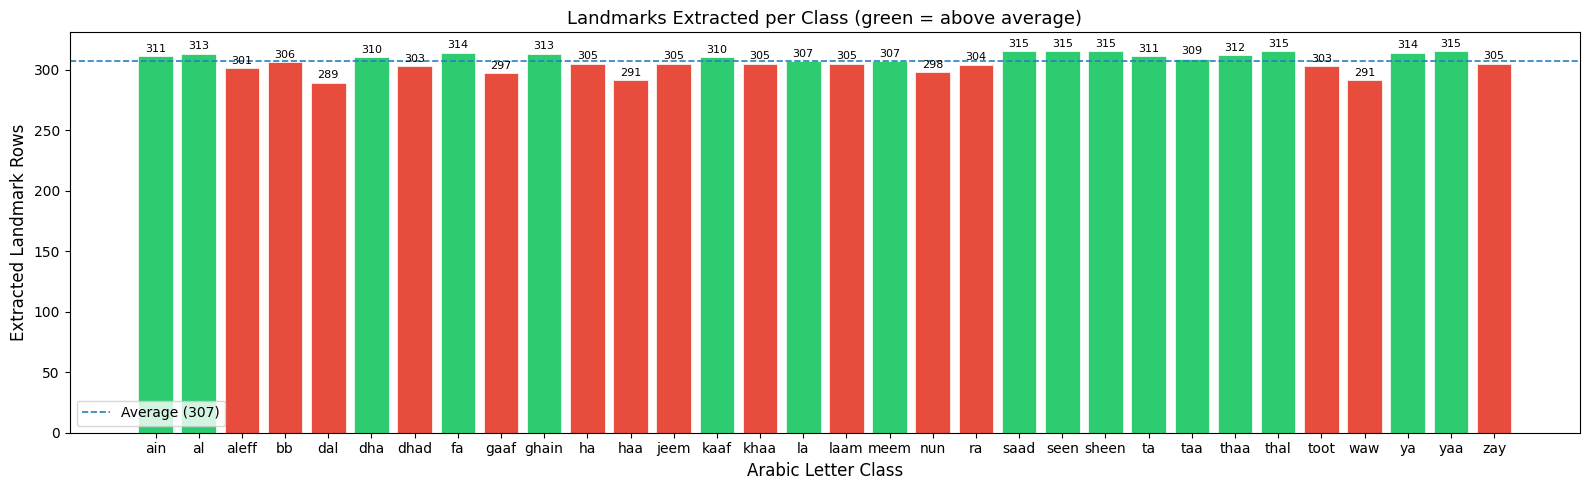

✅ Chart saved to ../outputs/extracted_per_class.png


I0000 00:00:1778862523.155685 5426217 gl_context.cc:357] GL version: 2.1 (2.1 ATI-5.1.35), renderer: AMD Radeon Pro 560X OpenGL Engine
/opt/anaconda3/envs/signlang/lib/python3.10/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
/var/folders/s0/gcsz2sx55sv9xyzhh5bv_k2c0000gn/T/ipykernel_93745/4197518393.py:306: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/s0/gcsz2sx55sv9xyzhh5bv_k2c0000gn/T/ipykernel_93745/4197518393.py:307: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("../outputs/sample_landmarks.png", dpi=150)
/opt/anaconda3/envs/signlang/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 998

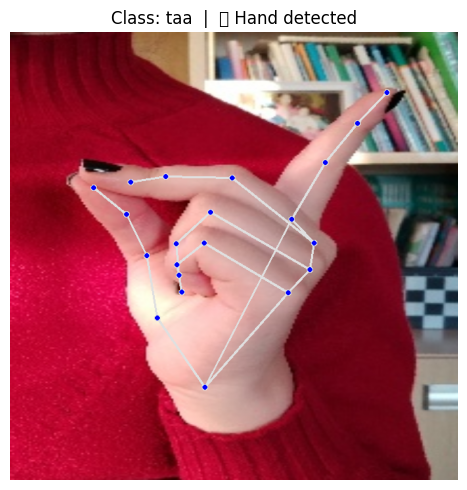

Image : ../datasets 2/train/images/168_16_F_taa_7.jpg
Class : taa
     NOTEBOOK 02 COMPLETE
  CSV file       : /Users/nadinehassan/Desktop/sign_language_translator_2/sign_language_translator/datasets 2/landmarks.csv
  Total rows     : 9,814
  Features/row   : 63  (21 landmarks × x, y, z)
  Classes saved  : 32
  Skipped images : 142

Next → Notebook 03: Train the classifier


In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import mediapipe as mp
import matplotlib.pyplot as plt
from tqdm import tqdm
import yaml
import random

# Sanity check versions
print("mediapipe :", mp.__version__)
print("opencv    :", cv2.__version__)
print("pandas    :", pd.__version__)
print("numpy     :", np.__version__)
print("\nAll imports OK")

# ── EDIT THESE PATHS IF NEEDED ────────────────────────────────────
DATASET_ROOT = "../datasets 2"
YAML_PATH    = "../datasets 2/sign.yaml"
OUTPUT_CSV   = "../datasets 2/landmarks.csv"
# ──────────────────────────────────────────────────────────────────

TRAIN_IMAGES = os.path.join(DATASET_ROOT, "train", "images")
TRAIN_LABELS = os.path.join(DATASET_ROOT, "train", "labels")
IMG_EXTS     = {".jpg", ".jpeg", ".png"}

assert os.path.isfile(YAML_PATH),   "❌ sign.yaml not found"
assert os.path.isdir(TRAIN_IMAGES), "❌ train/images not found"
assert os.path.isdir(TRAIN_LABELS), "❌ train/labels not found"

with open(YAML_PATH) as f:
    class_names = yaml.safe_load(f)["names"]

print(f"✅ Config OK — {len(class_names)} classes")
print(f"   Classes    : {class_names}")
print(f"   Output CSV : {os.path.abspath(OUTPUT_CSV)}")

# ══════════════════════════════════════════════════════════════════
# FIXED: yolo_to_pixel with padding so hand is never cut off
# ══════════════════════════════════════════════════════════════════
def yolo_to_pixel(cx, cy, w, h, img_w, img_h, padding=0.15):
    """
    Convert YOLO format to pixel coordinates.
    padding=0.15 adds 15% extra around the box on each side.
    """
    pad_w = w * padding
    pad_h = h * padding
    x1 = max(0,     int((cx - w/2 - pad_w) * img_w))
    y1 = max(0,     int((cy - h/2 - pad_h) * img_h))
    x2 = min(img_w, int((cx + w/2 + pad_w) * img_w))
    y2 = min(img_h, int((cy + h/2 + pad_h) * img_h))
    return x1, y1, x2, y2


# ══════════════════════════════════════════════════════════════════
# FIXED: extract_landmarks with 3 fallback strategies
# ══════════════════════════════════════════════════════════════════
def extract_landmarks(img_bgr, x1, y1, x2, y2, hands_detector):
    """
    Try 3 strategies to detect hand landmarks:
      1. Padded crop resized to 224x224
      2. Same crop resized to 640x640 (helps tiny hands)
      3. Full image resized to 640x640 (last resort)
    Returns list of 63 floats or None if all fail.
    """

    def run_mediapipe(img_rgb):
        result = hands_detector.process(img_rgb)
        if not result.multi_hand_landmarks:
            return None
        hand    = result.multi_hand_landmarks[0]
        wrist_x = hand.landmark[0].x
        wrist_y = hand.landmark[0].y
        wrist_z = hand.landmark[0].z
        lms = []
        for lm in hand.landmark:
            lms.append(lm.x - wrist_x)
            lms.append(lm.y - wrist_y)
            lms.append(lm.z - wrist_z)
        return lms

    # Strategy 1: padded crop at 224x224
    crop = img_bgr[y1:y2, x1:x2]
    if crop.size > 0:
        result = run_mediapipe(cv2.cvtColor(cv2.resize(crop, (224, 224)), cv2.COLOR_BGR2RGB))
        if result:
            return result

    # Strategy 2: padded crop at 640x640
    if crop.size > 0:
        result = run_mediapipe(cv2.cvtColor(cv2.resize(crop, (640, 640)), cv2.COLOR_BGR2RGB))
        if result:
            return result

    # Strategy 3: full image at 640x640
    result = run_mediapipe(cv2.cvtColor(cv2.resize(img_bgr, (640, 640)), cv2.COLOR_BGR2RGB))
    if result:
        return result

    return None


print("✅ Functions defined")
print("   - yolo_to_pixel  (with 15% padding)")
print("   - extract_landmarks (3 fallback strategies)")

# ══════════════════════════════════════════════════════════════════
# MAIN EXTRACTION LOOP
# ══════════════════════════════════════════════════════════════════
all_data          = []
processed         = 0
skipped_no_hand   = 0
skipped_no_image  = 0

label_files = sorted([f for f in os.listdir(TRAIN_LABELS) if f.endswith(".txt")])

print(f"\nFound {len(label_files)} label files in: {TRAIN_LABELS}")
print(f"Found class names: {class_names[:5]}...")

assert class_names[0] != 'images', \
    "❌ class_names is wrong! Check your YAML_PATH"

# FIXED: lower min_detection_confidence + model_complexity=1
hands = mp.solutions.hands.Hands(
    static_image_mode=True,
    max_num_hands=1,
    min_detection_confidence=0.1,   # was 0.3 — lower = catches more hands
    model_complexity=1,             # more accurate than default 0
)

print(f"\nStarting extraction with 3-strategy fallback...\n")

for lf in tqdm(label_files, desc="Extracting landmarks"):
    stem     = os.path.splitext(lf)[0]
    lbl_path = os.path.join(TRAIN_LABELS, lf)

    # Find matching image
    img_path = None
    for ext in IMG_EXTS:
        candidate = os.path.join(TRAIN_IMAGES, stem + ext)
        if os.path.exists(candidate):
            img_path = candidate
            break

    if img_path is None:
        skipped_no_image += 1
        continue

    img = cv2.imread(img_path)
    if img is None:
        skipped_no_image += 1
        continue

    img_h, img_w = img.shape[:2]

    with open(lbl_path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts  = line.split()
            cls_id = int(parts[0])
            cx, cy, w, h = map(float, parts[1:5])

            if cls_id >= len(class_names):
                skipped_no_hand += 1
                continue

            x1, y1, x2, y2 = yolo_to_pixel(cx, cy, w, h, img_w, img_h, padding=0.15)
            landmarks       = extract_landmarks(img, x1, y1, x2, y2, hands)

            if landmarks is None:
                skipped_no_hand += 1
                continue

            all_data.append(landmarks + [class_names[cls_id]])
            processed += 1

hands.close()

total = processed + skipped_no_hand + skipped_no_image
print(f"\n✅ Done!")
print(f"   Rows saved        : {processed:,}")
print(f"   Skipped (no hand) : {skipped_no_hand:,}")
print(f"   Skipped (no image): {skipped_no_image:,}")
print(f"   Total attempted   : {total:,}")
print(f"   Detection rate    : {processed/total*100:.1f}%")

# ══════════════════════════════════════════════════════════════════
# SAVE TO CSV
# ══════════════════════════════════════════════════════════════════
feature_cols = []
for i in range(21):
    feature_cols.extend([f'x{i}', f'y{i}', f'z{i}'])

all_columns = feature_cols + ['label']

df = pd.DataFrame(all_data, columns=all_columns)

os.makedirs(os.path.dirname(OUTPUT_CSV), exist_ok=True)
df.to_csv(OUTPUT_CSV, index=False)

print(f"\n✅ CSV saved to   : {os.path.abspath(OUTPUT_CSV)}")
print(f"   Rows           : {len(df):,}")
print(f"   Columns        : {len(df.columns)}  (63 features + 1 label)")
print(f"\nFirst 3 rows preview:")
print(df.head(3).to_string())

# ══════════════════════════════════════════════════════════════════
# VERIFY + STATS
# ══════════════════════════════════════════════════════════════════
df_check = pd.read_csv(OUTPUT_CSV)

print("\n" + "="*50)
print("VERIFICATION")
print("="*50)
print("Shape          :", df_check.shape)
print("Column count   :", len(df_check.columns))
print("Labels found   :", sorted(df_check['label'].unique()))
print("Any NaN values :", df_check.isnull().values.any())
print("\nImages per class:")
print(df_check['label'].value_counts().sort_index().to_string())

# ══════════════════════════════════════════════════════════════════
# CHART: rows per class
# ══════════════════════════════════════════════════════════════════
counts_per_class = df_check['label'].value_counts().sort_index()
avg              = counts_per_class.mean()
colors           = ['#2ecc71' if v >= avg else '#e74c3c' for v in counts_per_class.values]

fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(counts_per_class.index, counts_per_class.values,
              color=colors, edgecolor='white', linewidth=0.5)

ax.axhline(avg, color='#2980b9', linestyle='--', linewidth=1.2,
           label=f'Average ({avg:.0f})')
ax.set_xlabel("Arabic Letter Class", fontsize=12)
ax.set_ylabel("Extracted Landmark Rows", fontsize=12)
ax.set_title("Landmarks Extracted per Class (green = above average)", fontsize=13)
ax.legend()

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 2,
            str(int(bar.get_height())),
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
out_img = "../outputs/extracted_per_class.png"
os.makedirs(os.path.dirname(out_img), exist_ok=True)
plt.savefig(out_img, dpi=150)
plt.show()
print(f"✅ Chart saved to {out_img}")

# ══════════════════════════════════════════════════════════════════
# SAMPLE VISUALIZATION
# ══════════════════════════════════════════════════════════════════
mp_hands   = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils

all_images = [
    f for f in os.listdir(TRAIN_IMAGES)
    if os.path.splitext(f)[1].lower() in IMG_EXTS
]

sample_file = random.choice(all_images)
sample_path = os.path.join(TRAIN_IMAGES, sample_file)
stem        = os.path.splitext(sample_file)[0]
label_path  = os.path.join(TRAIN_LABELS, stem + ".txt")

img = cv2.imread(sample_path)
img_h, img_w = img.shape[:2]

sample_cls = "unknown"
annotated  = None

if os.path.isfile(label_path):
    with open(label_path) as f:
        line = f.readline().strip()
    if line:
        parts      = line.split()
        cls_id     = int(parts[0])
        cx, cy, w, h = map(float, parts[1:5])
        sample_cls = class_names[cls_id] if cls_id < len(class_names) else str(cls_id)

        x1, y1, x2, y2 = yolo_to_pixel(cx, cy, w, h, img_w, img_h, padding=0.15)
        crop = img[y1:y2, x1:x2]
        crop_640 = cv2.resize(crop, (640, 640))
        annotated = cv2.cvtColor(crop_640, cv2.COLOR_BGR2RGB).copy()

        with mp_hands.Hands(static_image_mode=True, max_num_hands=1,
                            min_detection_confidence=0.1) as hd:
            result = hd.process(annotated)

        detected = "❌ No hand detected"
        if result.multi_hand_landmarks:
            for hand_lms in result.multi_hand_landmarks:
                mp_drawing.draw_landmarks(annotated, hand_lms, mp_hands.HAND_CONNECTIONS)
            detected = "✅ Hand detected"

        plt.figure(figsize=(5, 5))
        plt.imshow(annotated)
        plt.title(f"Class: {sample_cls}  |  {detected}", fontsize=12)
        plt.axis('off')
        plt.tight_layout()
        plt.savefig("../outputs/sample_landmarks.png", dpi=150)
        plt.show()
        print(f"Image : {sample_path}")
        print(f"Class : {sample_cls}")

# ══════════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ══════════════════════════════════════════════════════════════════
skipped = skipped_no_hand if 'skipped_no_hand' in dir() else 'N/A'

print("=" * 50)
print("     NOTEBOOK 02 COMPLETE")
print("=" * 50)
print(f"  CSV file       : {os.path.abspath(OUTPUT_CSV)}")
print(f"  Total rows     : {len(df_check):,}")
print(f"  Features/row   : 63  (21 landmarks × x, y, z)")
print(f"  Classes saved  : {df_check['label'].nunique()}")
print(f"  Skipped images : {skipped}")
print("=" * 50)
print("\nNext → Notebook 03: Train the classifier")